## **Processamento dos dados -** *Tratamento de Missing Values em Séries de Frequência Mista*

### *O que encontrar neste documento:*
- uma visão inicial do dataset original;
- a aplicação do metodo **Expectation Maximization (EM)** como método experimental para imputacao global;
- a aplicação de **Interpolacao** para os valores internos em falta;
- o preenchimento dos **ragged edges** com **Auto-ARIMA** na fase final.

### *Para que serve este notebook:*
O objetivo é comparar, de forma organizada, como diferentes estratégias de imputaço alteram os dados originais. O EM trata-se como uma referencia inicial, a interpolação trata os valores internos e, por fim, o Auto-ARIMA é usado no fim para preencher os *ragged-edges*.


In [62]:
# Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from routine_data import EMimputation # Reutillizar a rotina do estudo da AE que contem o algoritmo de imputação EM
import warnings
from itertools import product

from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore')

from pmdarima import auto_arima as pmd_auto_arima

# high-quality figures (output)
%config InlineBackend.figure_format = 'svg'

In [63]:
# Dados de treino 
df = pd.read_csv('dados/train.csv')

In [64]:
for col in df.columns:
    print(f"{col:<30} | dtype: {df[col].dtype}")

Date                           | dtype: object
UNETOT_PT_ea-md                | dtype: float64
UNEO25_PT_ea-md                | dtype: float64
UNEU25_PT_ea-md                | dtype: float64
REER42_PT_ea-md                | dtype: float64
LTIRT_PT_ea-md                 | dtype: float64
IPMN_PT_ea-md                  | dtype: float64
IPCAG_PT_ea-md                 | dtype: float64
IPCOG_PT_ea-md                 | dtype: float64
IPDCOG_PT_ea-md                | dtype: float64
IPNDCOG_PT_ea-md               | dtype: float64
IPING_PT_ea-md                 | dtype: float64
IPNRG_PT_ea-md                 | dtype: float64
TRNMN_PT_ea-md                 | dtype: float64
TRNCAG_PT_ea-md                | dtype: float64
TRNCOG_PT_ea-md                | dtype: float64
TRNDCOG_PT_ea-md               | dtype: float64
TRNNDCOG_PT_ea-md              | dtype: float64
TRNING_PT_ea-md                | dtype: float64
TRNNRG_PT_ea-md                | dtype: float64
HICPOV_PT_ea-md                | dtype: f

In [65]:
print(df.describe().to_string())
print(df.isnull().sum().to_string())

       UNETOT_PT_ea-md  UNEO25_PT_ea-md  UNEU25_PT_ea-md  REER42_PT_ea-md  LTIRT_PT_ea-md  IPMN_PT_ea-md  IPCAG_PT_ea-md  IPCOG_PT_ea-md  IPDCOG_PT_ea-md  IPNDCOG_PT_ea-md  IPING_PT_ea-md  IPNRG_PT_ea-md  TRNMN_PT_ea-md  TRNCAG_PT_ea-md  TRNCOG_PT_ea-md  TRNDCOG_PT_ea-md  TRNNDCOG_PT_ea-md  TRNING_PT_ea-md  TRNNRG_PT_ea-md  HICPOV_PT_ea-md  HICPNEF_PT_ea-md  HICPG_PT_ea-md  HICPIN_PT_ea-md  HICPSV_PT_ea-md  HICPNG_PT_ea-md  ICONFIX_PT_ea-md  CCONFIX_PT_ea-md  ESENTIX_PT_ea-md  KCONFIX_PT_ea-md  RTCONFIX_PT_ea-md  SCONFIX_PT_ea-md  BCI_PT_ea-md  CCI_PT_ea-md  SHIX_PT_ea-md  GDP_PT_ea-qd  EXPGS_PT_ea-qd  IMPGS_PT_ea-qd  GFCE_PT_ea-qd  HFCE_PT_ea-qd  CONSD_PT_ea-qd  GCF_PT_ea-qd  GFCF_PT_ea-qd  GFACON_PT_ea-qd  GFAMG_PT_ea-qd  GNFCPS_PT_ea-qd  GNFCIR_PT_ea-qd  GHIR_PT_ea-qd  GHSR_PT_ea-qd  TEMP_PT_ea-qd  EMP_PT_ea-qd  SEMP_PT_ea-qd  THOURS_PT_ea-qd  EMPAG_PT_ea-qd  EMPIN_PT_ea-qd  EMPMN_PT_ea-qd  EMPCON_PT_ea-qd  EMPRT_PT_ea-qd  EMPIT_PT_ea-qd  EMPFC_PT_ea-qd  EMPRE_PT_ea-qd  EMPPR_PT_ea-

**Nota**: É possível verificar que existem 310 valores totais em cada série, contudo algumas como são trimestrais possuem NaN, verificando-se um máximo de 188 MissingValues.

In [66]:
df.head()

,Date,UNETOT_PT_ea-md,UNEO25_PT_ea-md,UNEU25_PT_ea-md,REER42_PT_ea-md,LTIRT_PT_ea-md,IPMN_PT_ea-md,IPCAG_PT_ea-md,IPCOG_PT_ea-md,IPDCOG_PT_ea-md,...,OILPRICEx_fred-md,CUSR0000SAC_fred-md,PCEPI_fred-md,S&P 500_fred-md,epu_pt_epu,unemployment_up_15_unemployment,exchange_exchange,PPIPT_ppi,inflation_target,OILPRICEx_fred-md_Eur
0,2000-01-01,5.6,4.4,12.7,96.14621,5.81,123.5,191.3,118.0,129.6,...,27.18,146.7,72.961,1425.59,107.096201,5.6,0.9791,21.5,2.1,27.760188
1,2000-02-01,5.4,4.1,13.0,95.12462,5.78,122.7,177.4,119.8,131.1,...,29.35,147.6,73.191,1388.87,105.539878,5.4,0.9714,21.9,1.8,30.214124
2,2000-03-01,5.3,4.0,12.4,94.49293,5.61,116.5,164.6,116.5,124.8,...,29.89,149.1,73.505,1442.21,68.844150,5.3,0.9553,21.2,1.5,31.288600
3,2000-04-01,5.2,3.9,12.8,94.90064,5.52,115.5,159.3,118.0,125.3,...,25.74,148.5,73.444,1461.36,70.292778,5.2,0.9085,20.0,2.1,28.332416
4,2000-05-01,5.3,4.0,13.1,94.96760,5.68,120.8,171.0,121.0,127.9,...,28.78,148.5,73.505,1418.48,78.451666,5.3,0.9303,17.9,2.5,30.936257


---

### **Organizacao inicial dos dados**

Nesta etapa o dataset foi dividido em subconjuntos mais interpretáveis. O objetivo é separar as váriaveis por **origem** e por **frequência temporal** facilitando a análise posterior.

Foram criados blocos específicos para:
- variáveis provenientes da area do euro (`EA`);
- variáveis provenientes da base `FRED-MD`;
- series **mensais** e series **trimestrais** da `EA`.


In [67]:
# EA DataFrame
df_ea = df.loc[:, df.columns.str.contains("ea")]
df_ea.insert(0, "Date", df["Date"])
#df_ea.columns

In [68]:
# FRED-MD DataFrame
df_fred = df.loc[:, df.columns.str.contains("fred")]
if "OILPRICEx_fred-md" in df_fred.columns:
    df_fred = df_fred.drop(columns=["OILPRICEx_fred-md"]) # pois temos a conversão para euros
df_fred.insert(0, "Date", df["Date"])
#df_fred.columns

In [69]:
# Monthly Data
ea_md = df.loc[:, df.columns.str.contains("ea-md")]
ea_md.insert(0, "Date", df["Date"])
#ea_md.columns

In [70]:
# Quimestral Data
ea_qd = df.loc[:, df.columns.str.contains("ea-qd")]
ea_qd.insert(0, "Date", df["Date"])
#ea_qd.columns

In [71]:
# Excluir a variável de preço do petróleo, pois temos a conversão para euros; tratamento da variável Data para indexação temporal
df["Date"] = pd.to_datetime(df["Date"])
df = (
    df
    .drop(columns=["OILPRICEx_fred-md"])
    .set_index("Date")
    .sort_index()
)

In [72]:
# Excluir a variável month e year
drop_cols = [col for col in ["month", "year"] if col in df.columns]
df = df.sort_index().drop(columns=drop_cols)

---




### **Expectation Maximization (EM)**

Esta secção aplica o algoritmo **Expectation Maximization** para imputar valores em falta no painel completo. O EM é útil quando se pretende explorar a estrutura conjunta das séries, aproveitando a informação comum entre variáveis para reconstruir observações omissas.

Depois da imputacao, a análise compara:
- a distribuição das séries originais e preenchidas;
- as diferencas de média nas variaveis trimestrais antes e após a imputação;

O objetivo aqui e perceber até que ponto o `EM` preserva a forma e a escala das séries observadas.


In [73]:

def apply_em_imputation(df, q0=99, opts=None, return_factors=False):
    """
    Aplica imputação EM a um DataFrame numérico.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame com valores numéricos e possíveis NaN.
    q0 : int, default=99
        Número de fatores. Se 99, usa o critério Bai-Ng.
    opts : dict or None
        Opções para o algoritmo EM.
    return_factors : bool, default=False
        Se True, devolve também o objeto com os fatores/componentes do EM.

    Returns
    -------
    df_EM : pd.DataFrame
        DataFrame preenchido com EM.
    pc : dict, opcional
        Estrutura devolvida pelo EMimputation.
    """
    if opts is None:
        opts = {"maxiter": 1000, "thresh": 1e-5, "out": 0}

    df_tmp = df.drop("inflation_target", axis=1)  # Excluir a variável de inflação alvo do processo de imputação, pois é a variável dependente. Porque podemos induzir data leakage
    # e enviesar a análise posterior se a variável alvo for usada para imputar as outras variáveis. A imputação deve ser feita apenas com as variáveis independentes, para preservar
    # a integridade da análise bivariada e evitar vazamento de informação.
    X = df_tmp.to_numpy(dtype=float).copy()
    X_EM, pc = EMimputation(X, q0=q0, opts=opts)

    df_EM = pd.DataFrame(
        X_EM,
        index=df_tmp.index,
        columns=df_tmp.columns
    )

    if return_factors:
        return df_EM, pc

    return df_EM

In [74]:
df_EM, pc = apply_em_imputation(df, return_factors=True)


Running iteration 0: error is 999.000000
Running iteration 10: error is   0.000097
Running iteration 20: error is   0.000033
Running iteration 30: error is   0.000020
Running iteration 40: error is   0.000014
Running iteration 50: error is   0.000011
EM converged after 57 iterations


In [75]:
# Comparação de médias entre as variáveis trimestrais originais e preenchidas

vars_q = (ea_qd.columns.intersection(df_EM.columns).intersection(df.columns))

means = pd.DataFrame({
    "mean_df": df[vars_q].mean(),          
    "mean_df_EM": df_EM[vars_q].mean()
})
means["diff"] = means["mean_df_EM"] - means["mean_df"]
means["abs_diff"] = means["diff"].abs()

# variável com maior afastamento
worst_var = means["abs_diff"].idxmax()
worst_row = means.loc[worst_var]

print(means.sort_values("abs_diff", ascending=False).head())  # topo das diferenças
print("\nMaior afastamento:", worst_var)
print(worst_row)


                        mean_df    mean_df_EM         diff     abs_diff
THOURS_PT_ea-qd    2.302904e+06  2.299999e+06 -2905.098517  2905.098517
TASS.LLN_PT_ea-qd  3.057675e+05  3.042685e+05 -1499.025334  1499.025334
GGLB_PT_ea-qd      2.502390e+05  2.515387e+05  1299.678609  1299.678609
HHASS_PT_ea-qd     3.685305e+05  3.696971e+05  1166.514612  1166.514612
TLB.LLN_PT_ea-qd   3.621747e+05  3.613931e+05  -781.630263   781.630263

Maior afastamento: THOURS_PT_ea-qd
mean_df       2.302904e+06
mean_df_EM    2.299999e+06
diff         -2.905099e+03
abs_diff      2.905099e+03
Name: THOURS_PT_ea-qd, dtype: float64


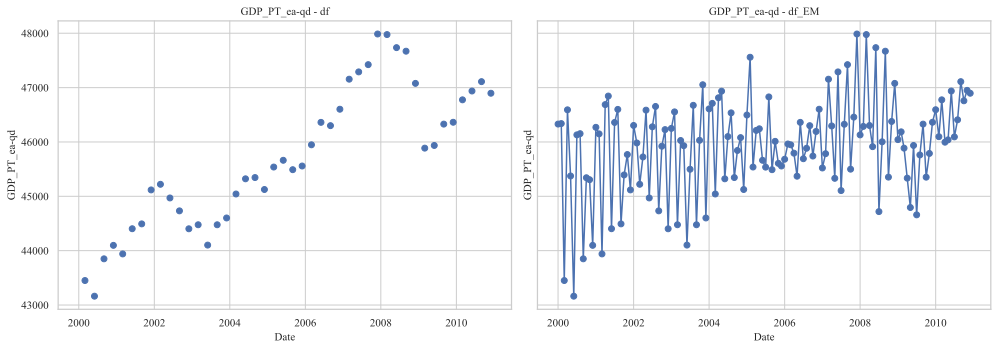

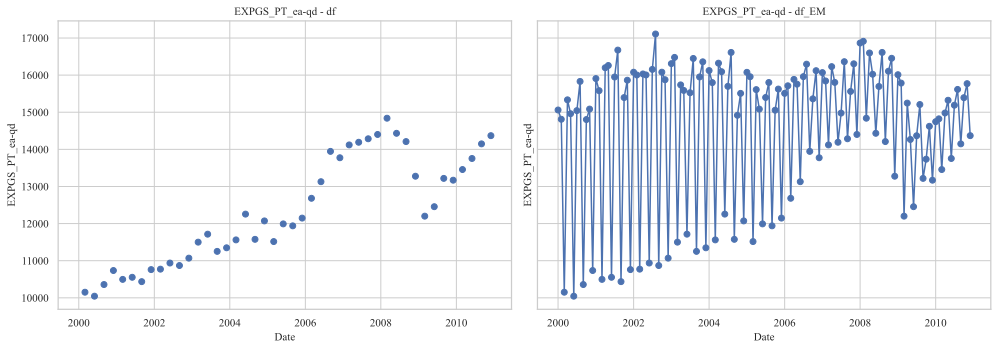

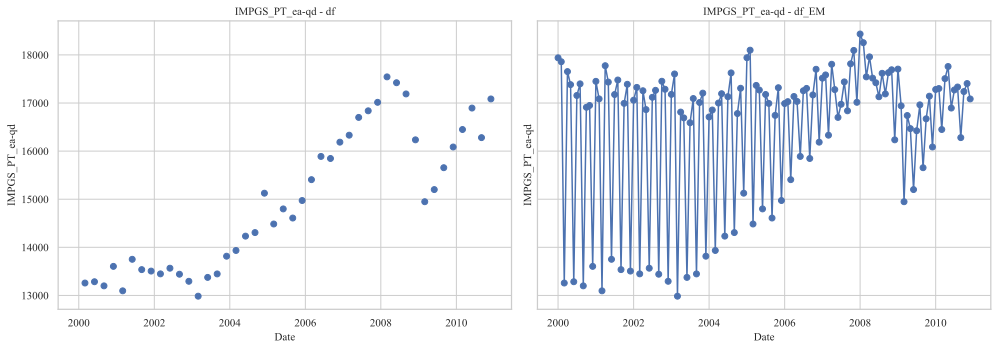

In [76]:
# Comparação lado a lado das séries trimestrais originais e preenchidas com EM
start, end = "2000-01-01", "2010-12-01"
vars_q = [col for col in ea_qd.columns if col != "Date" and col in df.columns and col in df_EM.columns]

for col in vars_q[:3]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    fig.subplots_adjust(wspace=0.25)

    # Série original
    serie_df = df.loc[start:end, col].dropna()
    axes[0].plot(serie_df.index, serie_df.values, marker="o", linestyle="None")
    axes[0].set_title(f"{col} - df")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel(col)
    axes[0].grid(True)

    # Série preenchida com EM
    serie_EM = df_EM.loc[start:end, col].dropna()
    axes[1].plot(serie_EM.index, serie_EM.values, marker="o", linestyle="-")
    axes[1].set_title(f"{col} - df_EM")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel(col)
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


---

### **Interpolação**

Nesta fase testa-se a imputacao por **interpolação temporal**, uma alternativa mais local ao EM. Em vez de usar a estrutura conjunta de todo o painel, a interpolação reconstrói os valores em falta a partir da própria dinâmica de cada série.

***Teste de varios metodos e escolha por proximidade da média:***

A estratégia seguida consiste em experimentar vários métodos de interpolação mantendo os restantes parâmetros fixos. Para cada série com valores em falta, compara-se a média original com a média após o preenchimento. O método eligido é aquele que produz a menor diferença absoluta das médias. Este critério é simples e fácil de interpretar, servindo como filtro inicial para identificar o método que menos altera o nível médio da série.


In [77]:
# Função para aplicar o melhor método de interpolação em cada série

def interpolate_best_by_series(
    df,
    metodos=None,
    limit=2,
    limit_direction="both",
    limit_area="inside",
    spline_order=3,
    return_info=True
):
    if metodos is None:
        metodos = [
            "linear",
            "time",
            "index",
            "nearest",
            "slinear",
            "quadratic",
            "cubic",
            "pchip",
            "akima",
            "cubicspline",
            "spline",
            "polynomial"
        ]



    df_base = df.copy()

    # se o índice não for datetime, o método "time" não funciona corretamente
    if not isinstance(df_base.index, pd.DatetimeIndex):
        metodos = [m for m in metodos if m != "time"]

    df_best = df_base.copy()
    resultados = []

    for col in df_base.columns:
        s = df_base[col]

        # ignorar colunas sem NaN
        if not s.isna().any():
            continue

        media_original = s.mean(skipna=True)

        melhor_diff = np.inf
        melhor_serie = s.copy()

        for metodo in metodos:
            try:
                kwargs = {
                    "method": metodo,
                    "limit": limit,
                    "limit_direction": limit_direction,
                    "limit_area": limit_area
                }

                # métodos que precisam de ordem
                if metodo in ["polynomial", "spline"]:
                    kwargs["order"] = spline_order

                s_fill = s.interpolate(**kwargs)

                media_fill = s_fill.mean(skipna=True)
                diff = abs(media_fill - media_original)

                resultados.append({
                    "serie": col,
                    "metodo": metodo,
                    "media_original": media_original,
                    "media_preenchida": media_fill,
                    "diff_media": diff
                })

                if diff < melhor_diff:
                    melhor_diff = diff
                    melhor_serie = s_fill

            except Exception:
                continue

        df_best[col] = melhor_serie

    resumo_metodos = pd.DataFrame(resultados)

    if resumo_metodos.empty:
        melhor_por_serie = pd.DataFrame(
            columns=["serie", "metodo", "media_original", "media_preenchida", "diff_media"]
        )
    else:
        resumo_metodos = resumo_metodos.sort_values(["serie", "diff_media"]).reset_index(drop=True)
        melhor_por_serie = (
            resumo_metodos
            .groupby("serie", as_index=False)
            .first()
            .sort_values("diff_media")
            .reset_index(drop=True)
        )

    if return_info:
        return df_best, melhor_por_serie, resumo_metodos

    return df_best



In [78]:
df_interpolated, info_melhores, info_completa = interpolate_best_by_series(df)

print(info_melhores.to_string())

                  serie       metodo  media_original  media_preenchida   diff_media
0         RPRP_PT_ea-qd         time    9.672988e+01      9.672986e+01     0.000025
1       GNFCPS_PT_ea-qd        cubic    3.838745e+01      3.839192e+01     0.004473
2       GNFCIR_PT_ea-qd        cubic    2.561649e+01      2.561193e+01     0.004564
3        EMPFC_PT_ea-qd        cubic    8.722660e+01      8.721789e+01     0.008708
4         GHSR_PT_ea-qd         time    9.350638e+00      9.339766e+00     0.010872
5        DFGDP_PT_ea-qd       spline    9.597529e+01      9.596368e+01     0.011608
6        NFCLB_PT_ea-qd        pchip    5.581700e+05      5.581700e+05     0.012841
7         GHIR_PT_ea-qd       linear    7.086809e+00      7.070571e+00     0.016237
8        ULCIN_PT_ea-qd        cubic    8.444043e+01      8.442296e+01     0.017461
9        ULCRE_PT_ea-qd       linear    1.001589e+02      1.001806e+02     0.021708
10       ULCMQ_PT_ea-qd        cubic    8.940111e+01      8.937668e+01     0

In [79]:
# Comparação de médias entre as variáveis trimestrais originais e preenchidas

vars_q = ( ea_qd.columns.intersection(df_interpolated.columns).intersection(df.columns))

means = pd.DataFrame({
    "mean_df": df[vars_q].mean(),          
    "mean_df_interpolated": df_interpolated[vars_q].mean()
})
means["diff"] = means["mean_df_interpolated"] - means["mean_df"]
means["abs_diff"] = means["diff"].abs()

# variável com maior afastamento
worst_var = means["abs_diff"].idxmax()
worst_row = means.loc[worst_var]

print(means.sort_values("abs_diff", ascending=False).head())  # topo das diferenças
print("\nMaior afastamento:", worst_var)
print(worst_row)


                         mean_df  mean_df_interpolated         diff  \
THOURS_PT_ea-qd     2.302904e+06          2.301884e+06 -1019.914742   
TLB.LLN_PT_ea-qd    3.621747e+05          3.627518e+05   577.080167   
TASS.LLN_PT_ea-qd   3.057675e+05          3.063268e+05   559.250152   
HHLB.LLN_PT_ea-qd   1.260715e+05          1.262529e+05   181.329172   
NFCLB.LLN_PT_ea-qd  1.351518e+05          1.353294e+05   177.594992   

                       abs_diff  
THOURS_PT_ea-qd     1019.914742  
TLB.LLN_PT_ea-qd     577.080167  
TASS.LLN_PT_ea-qd    559.250152  
HHLB.LLN_PT_ea-qd    181.329172  
NFCLB.LLN_PT_ea-qd   177.594992  

Maior afastamento: THOURS_PT_ea-qd
mean_df                 2.302904e+06
mean_df_interpolated    2.301884e+06
diff                   -1.019915e+03
abs_diff                1.019915e+03
Name: THOURS_PT_ea-qd, dtype: float64


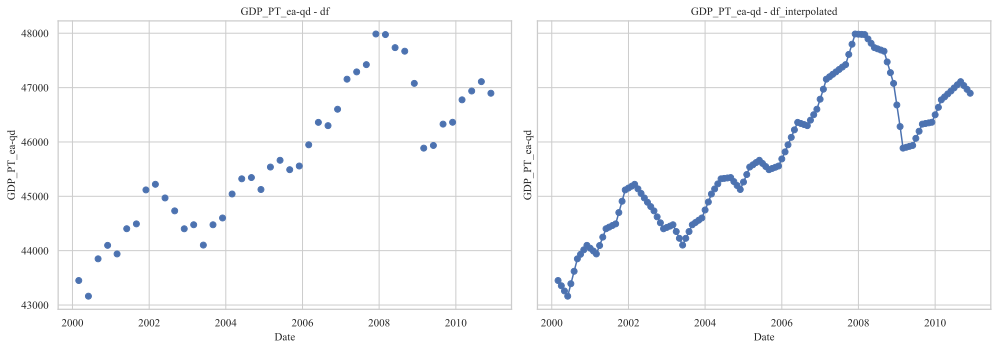

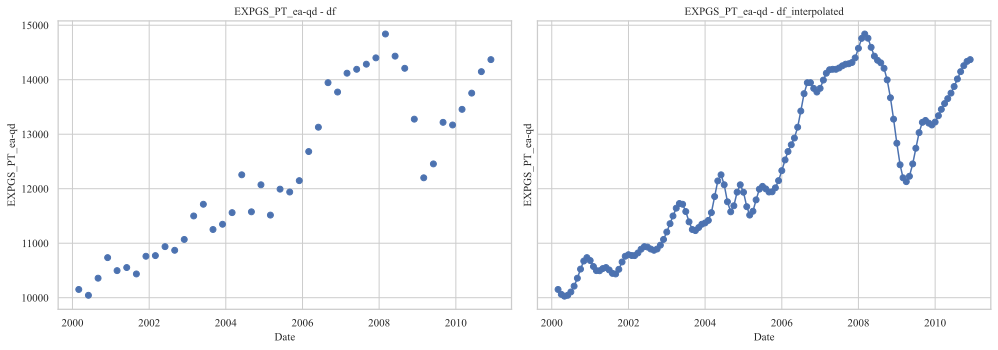

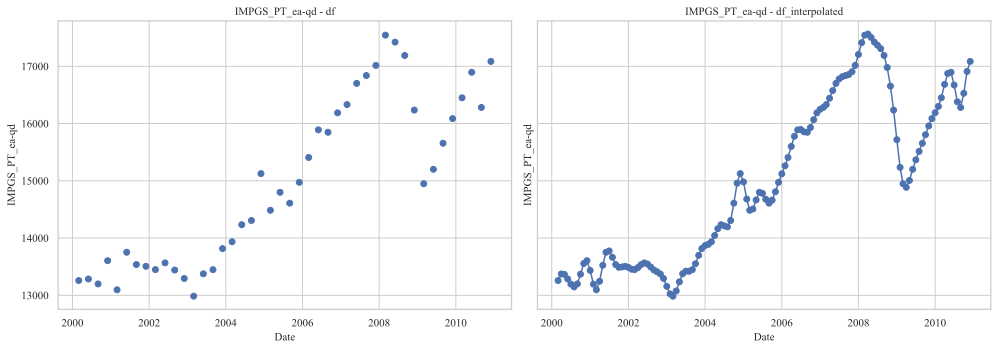

In [80]:
# Comparação lado a lado das séries trimestrais originais e preenchidas com Interpolate
start, end = "2000-01-01", "2010-12-01"
vars_q = [col for col in ea_qd.columns if col != "Date" and col in df.columns and col in df_interpolated.columns]

for col in vars_q[:3]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    fig.subplots_adjust(wspace=0.25)

    # Série original
    serie_df = df.loc[start:end, col].dropna()
    axes[0].plot(serie_df.index, serie_df.values, marker="o", linestyle="None")
    axes[0].set_title(f"{col} - df")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel(col)
    axes[0].grid(True)

    # Série preenchida com Interpolate
    serie_interpolate = df_interpolated.loc[start:end, col].dropna()
    axes[1].plot(serie_interpolate.index, serie_interpolate.values, marker="o", linestyle="-")
    axes[1].set_title(f"{col} - df_interpolated")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel(col)
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


---


## **Preenchimento dos ragged edges com Auto-ARIMA**

Nesta fase, o ponto de partida é o `df_interpolated`: a interpolacao ja tratou os valores internos, pelo que o objetivo passa a ser preencher apenas os `ragged edges`, isto é:
- valores antes do primeiro valor observado;
- valores depois do ultimo valor observado.

As series sao modeladas no dominio estacionario e, no fim, os valores previstos nas pontas sao revertidos para a escala original. Os valores internos de `df_interpolated` mantem-se inalterados.

### **Transformações utilizadas**

As transformações seguem a base de dados de origem:

**EA/PT (`TR1`)**
- `1`: `100 * log(x_t)`
- `2`: `100 * diff(log(x_t))`
- `3`: `100 * diff(log(x_t), 2)`
- `4`: `x_t`
- `5`: `diff(x_t)`

**FRED**
- `1`: `x_t`
- `2`: `diff(x_t)`
- `3`: `diff(x_t, 2)`
- `4`: `log(x_t)`
- `5`: `diff(log(x_t))`
- `6`: `diff(log(x_t), 2)`
- `7`: `diff(x_t / x_{t-1} - 1)`

Depois do ajuste do Auto-ARIMA:
- faz-se `forecast` para os *ragged edges*, quando necessario;
- os valores previstos sao revertidos para a escala original de cada variavel de acordo com a respetiva transformacao.


In [81]:
# FRED columns 
cols_fred_global = [
    'INDPRO', 'IPFINAL', 'IPCONGD',
    'AWOTMAN', 'AWHMAN', 'FEDFUNDS', 'GS1', 'GS5',
    'GS10', 'AAA', 'BAA', 'OILPRICEx', 'CUSR0000SAC',
    'PCEPI', 'S&P 500'
]

new_name = {col:f'{col}_fred-md' for col in cols_fred_global}

# Load the FRED‑MD dataset to apply the corresponding transformations
df_fred_md = pd.read_csv("dados/2026-01-MD.csv")[cols_fred_global].rename(new_name, axis=1)
 
# Alterar o nome para a variáel em euros, a qual irá ser utilizada
df_fred_md.rename({'OILPRICEx_fred-md': 'OILPRICEx_fred-md_Eur'}, axis=1, inplace=True)


In [82]:
# Mapas de código de transformação para FRED-MD e EA-MD-QD

def stacionarize_fred(X, code):
    if code == 1: return X
    elif code == 2: return X.diff()
    elif code == 3: return X.diff(2)
    elif code == 4: return np.log(X)
    elif code == 5: return np.log(X).diff()
    elif code == 6: return np.log(X).diff(2)
    elif code == 7: return (X/X.shift() - 1).diff()
    else: raise ValueError(f'Unsupported FRED transformation code: {code}')


def stacionarize_ea(X, code):
    if code == 1: return 100 * stacionarize_fred(X, 4)
    elif code == 2: return 100 * stacionarize_fred(X, 5)
    elif code == 3: return 100 * stacionarize_fred(X, 6)
    elif code == 4: return X
    elif code == 5: return stacionarize_fred(X, 2)
    else: raise ValueError(f'Unsupported EA/PT transformation code: {code}')



In [83]:
# Read EA-MD-QD info for transformation mapping
df_ea_md_qd = pd.read_excel("dados/EA-MD-QD-2026-02/PTdata.xlsx", sheet_name='info')[['Name', 'TR1', 'Frequency']]

ea_transform = dict()
for idx in range(df_ea_md_qd.shape[0]):
    name, val, freq = df_ea_md_qd.iloc[idx]
    name = f'{name}_ea-md' if freq == 'M' else f'{name}_ea-qd'
    ea_transform[name] = val

pd.Series(ea_transform)[0:10]

df_stacionary = df[['inflation_target', 'unemployment_up_15_unemployment']].copy() # a variavel alvo e a taxa de desemprego já são estacionárias

df_stacionary['epu_pt_epu'] = stacionarize_fred(df['epu_pt_epu'], 2) # aplica-se a transformação de diferença simples


In [84]:
# Estacionarizando as variáveis da FRED-MD
for idx, val in df_fred_md.iloc[0].items():
    df_stacionary[idx] = stacionarize_fred(df[idx], val) 
    
# Estacionarizando as variáveis da EA-MD-QD
for idx, val in pd.Series(ea_transform).items():
    df_stacionary[idx] = stacionarize_ea(df_interpolated[idx], val)



covered_cols = set(df_stacionary.columns) | {'Date'}
remaining_cols = [c for c in df_stacionary.columns if c not in covered_cols]
if remaining_cols:
    print("Colunas mantidas fora da etapa de estacionarizacao automatica:")
    print(remaining_cols)

print(f'Dataset estacionario criado com {df_stacionary.shape[1]} colunas.')
display(df_stacionary.head())


Dataset estacionario criado com 117 colunas.


,inflation_target,unemployment_up_15_unemployment,epu_pt_epu,INDPRO_fred-md,IPFINAL_fred-md,IPCONGD_fred-md,AWOTMAN_fred-md,AWHMAN_fred-md,FEDFUNDS_fred-md,GS1_fred-md,...,DFGDP_PT_ea-qd,ICONFIX_PT_ea-md,CCONFIX_PT_ea-md,ESENTIX_PT_ea-md,KCONFIX_PT_ea-md,RTCONFIX_PT_ea-md,SCONFIX_PT_ea-md,BCI_PT_ea-md,CCI_PT_ea-md,SHIX_PT_ea-md
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,2.1,5.6,NaN,NaN,NaN,NaN,NaN,41.5,NaN,NaN,...,NaN,7.3,-2.4,113.9,NaN,9.4,10.3,102.2262,102.3880,NaN
2000-02-01,1.8,5.4,-1.556323,0.003118,0.005419,0.006679,0.1,41.5,0.28,0.10,...,NaN,8.9,-3.0,116.7,10.2,11.0,14.2,102.5146,102.2470,12.366348
2000-03-01,1.5,5.3,-36.695728,0.003549,0.000055,-0.004811,-0.3,41.4,0.12,0.00,...,NaN,7.7,-3.2,116.2,5.5,11.7,11.9,102.6476,101.9521,2.686605
2000-04-01,2.1,5.2,1.448628,0.005935,0.007305,0.007288,0.1,41.6,0.17,-0.07,...,-0.241874,8.8,-9.2,114.1,-13.4,6.1,13.2,102.7988,101.5175,-10.407950
2000-05-01,2.5,5.3,8.158889,0.002704,0.002443,0.000960,-0.1,41.2,0.25,0.18,...,0.362385,10.1,-8.0,113.3,9.8,1.5,6.0,102.8972,101.2843,-3.188878


---

### **Funcoes de transformacao, identificacao dos edges e reversao das séries estacionárias**

Nesta etapa, `df_interpolated` continua a ser o dataset de referencia na escala original: e nele que os `ragged edges` sao identificados e e nele que os valores finais sao recolocados. O `df_stacionary` e usado apenas como input estacionario para o Auto-ARIMA.


In [85]:
# df_ragged_base: series na escala original, apos a interpolacao dos NaN internos
# Serve para identificar os ragged edges e para receber os valores finais imputados
df_ragged_base = df_interpolated.copy()

# df_stacionary_ragged: versao estacionaria ja criada nas celulas anteriores
# Serve apenas para ajustar o Auto-ARIMA
df_stacionary_ragged = df_stacionary.copy()

raw_transform_specs = {}

# EA transforms
for col, code in ea_transform.items():
    if col in df_ragged_base.columns:
        raw_transform_specs[col] = {
            'transform_group': 'ea',
            'code': int(code)
        }

# FRED transforms
for col, code in df_fred_md.iloc[0].items():
    if col in df_ragged_base.columns:
        raw_transform_specs[col] = {
            'transform_group': 'fred',
            'code': int(code)
        }

if 'epu_pt_epu' in df_ragged_base.columns:
    raw_transform_specs['epu_pt_epu'] = {'transform_group': 'fred', 'code': 2}
if 'inflation_target' in df_ragged_base.columns:
    raw_transform_specs['inflation_target'] = {'transform_group': 'identity', 'code': 1}
if 'unemployment_up_15_unemployment' in df_ragged_base.columns:
    raw_transform_specs['unemployment_up_15_unemployment'] = {'transform_group': 'identity', 'code': 1}



def get_ragged_edges(series_base):
    valid = series_base.dropna()
    if valid.empty:
        return None

    first_idx = valid.index[0]
    last_idx = valid.index[-1]
    first_loc = series_base.index.get_loc(first_idx)
    last_loc = series_base.index.get_loc(last_idx)
    inner_gap = series_base.iloc[first_loc:last_loc + 1].isna().any()

    return {
        'first_idx': first_idx,                                 # indice do primeiro valor observado
        'last_idx': last_idx,                                   # indice do ultimo valor observado
        'first_loc': first_loc,                                 # posicao do primeiro valor observado
        'last_loc': last_loc,                                   # posicao do ultimo valor observado
        'lead_original_idx': series_base.index[:first_loc],     # datas antes do primeiro observado
        'trail_original_idx': series_base.index[last_loc + 1:], # datas depois do ultimo observado
        'has_internal_nan': bool(inner_gap)                     # True se ainda existir algum NaN no interior
    }


# Quantas observacoes iniciais passam a NaN depois da transformacao estacionaria
def get_stationary_offset(transform_group, code):
    if transform_group == 'identity':
        return 0
    if transform_group == 'ea':
        if code in (1, 4):
            return 0
        if code in (2, 5):
            return 1
        if code == 3:
            return 2
    if transform_group == 'fred':
        if code in (1, 4):
            return 0
        if code in (2, 5):
            return 1
        if code in (3, 6, 7):
            return 2
    raise ValueError(f'Unsupported transformation specification: transform_group={transform_group}, code={code}')


# Converte as pontas da serie original para as posicoes equivalentes na serie estacionaria
def get_stationary_edge_idx(series_index, edge_info, transform_group, code):
    offset = get_stationary_offset(transform_group, code)
    first_loc = edge_info['first_loc']
    last_loc = edge_info['last_loc']
    lead_idx = series_index[offset:first_loc + offset] if first_loc > 0 else series_index[:0]
    trail_idx = series_index[last_loc + 1:] if last_loc < len(series_index) - 1 else series_index[:0]
    return lead_idx, trail_idx


def restore_original_scale(series_base, stationary_filled, transform_group, code, edge_info):
    """
    Reverte os valores imputados na série estacionária para a escala original da variável,
    apenas nas séries com ragged edges.

    A função usa a série original como âncora para desfazer a transformação aplicada
    na etapa de estacionarização e reconstruir, em nível, apenas os valores previstos
    nas pontas da série.

    Parameters
    ----------
    series_base : pd.Series
        Série na escala original, com valores observados e NaN nas pontas.
    stationary_filled : pd.Series
        Série já estacionária, depois de preenchidos os ragged edges com ARIMA.
    transform_group : str
        Grupo de transformação usado na estacionarização ('ea', 'fred' ou 'identity').
    code : int
        Código da transformação aplicada à série.
    edge_info : dict
        Informação sobre a localização dos ragged edges, incluindo primeiro e último
        valor observado, posições no índice e índices das pontas em falta.

    Returns
    -------
    restored : pd.Series
        Série reconstruída na escala original, com os ragged edges imputados.
    """
    
    restored = series_base.astype(float).copy() # Parte da série original. logo os valores observados já estão na escala original
    first_idx, last_idx = edge_info['first_idx'], edge_info['last_idx']
    first_loc, last_loc = edge_info['first_loc'], edge_info['last_loc']
    lead_idx = edge_info['lead_original_idx']
    trail_idx = edge_info['trail_original_idx']

    if (transform_group == 'identity' or (transform_group == 'ea' and code == 4) or (transform_group == 'fred' and code == 1)):
        edge_idx = lead_idx.union(trail_idx)
        restored.loc[edge_idx] = stationary_filled.loc[edge_idx]
        return restored

    if (transform_group == 'ea' and code == 1 or (transform_group == 'fred' and code == 4)):
        scale = 100.0 if transform_group == 'ea' else 1.0
        edge_idx = lead_idx.union(trail_idx)
        restored.loc[edge_idx] = np.exp(stationary_filled.loc[edge_idx] / scale)
        return restored

    if (transform_group == 'ea' and code == 2) or (transform_group == 'fred' and code == 5):
        scale = 100.0 if transform_group == 'ea' else 1.0 # corrigir a escala pois difere entre variaveis da EA e da FRED
        log_levels = pd.Series(index=restored.index, dtype=float)
        observed_slice = restored.loc[first_idx:last_idx]
        log_levels.loc[observed_slice.index] = np.log(observed_slice)

        for pos in range(first_loc, 0, -1):
            curr_idx = restored.index[pos]
            prev_idx = restored.index[pos - 1]
            log_levels.loc[prev_idx] = log_levels.loc[curr_idx] - stationary_filled.loc[curr_idx] / scale

        for pos in range(last_loc + 1, len(restored.index)):
            curr_idx = restored.index[pos]
            prev_idx = restored.index[pos - 1]
            log_levels.loc[curr_idx] = log_levels.loc[prev_idx] + stationary_filled.loc[curr_idx] / scale

        # Nota: entre lead_idx e trail_idx os valores já estão em nível
        edge_idx = lead_idx.union(trail_idx)
        restored.loc[edge_idx] = np.exp(log_levels.loc[edge_idx])
        return restored


    if (transform_group == 'ea' and code == 5) or (transform_group == 'fred' and code == 2):
        levels = restored.copy()

        for pos in range(first_loc, 0, -1):
            curr_idx = restored.index[pos]
            prev_idx = restored.index[pos - 1]
            levels.loc[prev_idx] = levels.loc[curr_idx] - stationary_filled.loc[curr_idx]

        for pos in range(last_loc + 1, len(restored.index)):
            curr_idx = restored.index[pos]
            prev_idx = restored.index[pos - 1]
            levels.loc[curr_idx] = levels.loc[prev_idx] + stationary_filled.loc[curr_idx]

        edge_idx = lead_idx.union(trail_idx)
        restored.loc[edge_idx] = levels.loc[edge_idx]
        return restored
    

    if transform_group == 'fred' and code == 3:
        levels = restored.copy()

        for pos in range(first_loc + 1, 1, -1):
            curr_idx = restored.index[pos]
            prev2_idx = restored.index[pos - 2]
            levels.loc[prev2_idx] = levels.loc[curr_idx] - stationary_filled.loc[curr_idx]

        for pos in range(last_loc + 1, len(restored.index)):
            curr_idx = restored.index[pos]
            prev2_idx = restored.index[pos - 2]
            levels.loc[curr_idx] = levels.loc[prev2_idx] + stationary_filled.loc[curr_idx]

        edge_idx = lead_idx.union(trail_idx)
        restored.loc[edge_idx] = levels.loc[edge_idx]
        return restored


    if (transform_group == 'ea' and code == 3) or (transform_group == 'fred' and code == 6):
        scale = 100.0 if transform_group == 'ea' else 1.0
        log_levels = pd.Series(index=restored.index, dtype=float)
        observed_slice = restored.loc[first_idx:last_idx]
        log_levels.loc[observed_slice.index] = np.log(observed_slice)

        for pos in range(first_loc + 1, 1, -1):
            curr_idx = restored.index[pos]
            prev2_idx = restored.index[pos - 2]
            log_levels.loc[prev2_idx] = log_levels.loc[curr_idx] - stationary_filled.loc[curr_idx] / scale

        for pos in range(last_loc + 1, len(restored.index)):
            curr_idx = restored.index[pos]
            prev2_idx = restored.index[pos - 2]
            log_levels.loc[curr_idx] = log_levels.loc[prev2_idx] + stationary_filled.loc[curr_idx] / scale

        edge_idx = lead_idx.union(trail_idx)
        restored.loc[edge_idx] = np.exp(log_levels.loc[edge_idx])
        return restored


    raise ValueError(f'Unsupported restoration rule for transform_group={transform_group}, code={code}')


ragged_specs = {}
internal_nan_cols = []
unmapped_nan_cols = []

for col, spec in raw_transform_specs.items():
    edge_info = get_ragged_edges(df_ragged_base[col].astype(float))
    if edge_info is None:
        continue
    if edge_info['has_internal_nan']:
        internal_nan_cols.append(col)
        continue
    if len(edge_info['lead_original_idx']) > 0 or len(edge_info['trail_original_idx']) > 0:
        ragged_specs[col] = spec

for col in df_ragged_base.columns:
    if col in raw_transform_specs:
        continue
    edge_info = get_ragged_edges(df_ragged_base[col].astype(float))
    if edge_info is None:
        continue
    if edge_info['has_internal_nan'] or len(edge_info['lead_original_idx']) > 0 or len(edge_info['trail_original_idx']) > 0:
        unmapped_nan_cols.append(col)

print(f'Series com ragged edges e transformacao conhecida: {len(ragged_specs)}')
if internal_nan_cols:
    print('Series com NaN internos, fora do ambito desta etapa:')
    print(internal_nan_cols)
if unmapped_nan_cols:
    print('Series com NaN mas sem mapeamento de transformacao:')
    print(unmapped_nan_cols)


Series com ragged edges e transformacao conhecida: 65


### **Funcoes de modelacao ARIMA, forecast nos ragged edges**

O Auto-ARIMA e ajustado apenas sobre a serie estacionaria. A localizacao dos `ragged edges` vem sempre da serie original em `df_ragged_base`, e no fim as previsoes sao revertidas para essa escala original.


In [86]:
def fit_auto_arima_stationary(y, max_p=8, max_q=8, seasonal=False, m=12, reverse=False):
    y = pd.Series(y).dropna().astype(float)
    if y.empty:
        raise ValueError('No stationary observations available for ARIMA fitting.')
    if y.nunique() <= 1:
        return {
            'engine': 'constant',
            'order': (0, 0, 0),
            'constant_value': float(y.iloc[0])
        }
    if y.shape[0] < 8:
        raise ValueError('Too few stationary observations to fit an ARIMA model reliably.')

    y_fit = y.iloc[::-1].reset_index(drop=True) if reverse else y.reset_index(drop=True)

    if 'pmd_auto_arima' in globals():
        model = pmd_auto_arima(
            y_fit,
            start_p=0,
            start_q=0,
            max_p=max_p,
            max_q=max_q,
            d=0,
            seasonal=seasonal,
            m=m,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            with_intercept=True,
            information_criterion='aic'
        )
        return {
            'engine': 'pmdarima',
            'order': tuple(model.order),
            'model': model
        }

    best_model = None
    best_order = None
    best_aic = np.inf
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            try:
                fitted = ARIMA(
                    y_fit,
                    order=(p, 0, q),
                    trend='c',
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit()
                if np.isfinite(fitted.aic) and fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_model = fitted
                    best_order = (p, 0, q)
            except Exception:
                continue

    if best_model is None:
        best_model = ARIMA(y_fit, order=(0, 0, 0), trend='c', enforce_stationarity=False, enforce_invertibility=False).fit()
        best_order = (0, 0, 0)

    return {
        'engine': 'statsmodels-grid',
        'order': best_order,
        'model': best_model
    }


def predict_stationary_edge(model_info, n_periods):
    if n_periods <= 0:
        return np.array([], dtype=float)
    if model_info['engine'] == 'constant':
        return np.repeat(model_info['constant_value'], n_periods).astype(float)
    if model_info['engine'] == 'pmdarima':
        return np.asarray(model_info['model'].predict(n_periods=n_periods), dtype=float)
    return np.asarray(model_info['model'].forecast(steps=n_periods), dtype=float)


def fill_ragged_edges_one_series(col, spec, seasonal=False, max_p=8, max_q=8):
    base_series = df_ragged_base[col].astype(float)
    stationary_series = df_stacionary_ragged[col].reindex(base_series.index).astype(float)
    edge_info = get_ragged_edges(base_series)

    if edge_info is None:
        return base_series, {'status': 'skipped', 'message': 'Series has no observed values.'}, stationary_series, stationary_series.copy()
    if edge_info['has_internal_nan']:
        return base_series, {'status': 'skipped', 'message': 'Series still has internal missing values.'}, stationary_series, stationary_series.copy()
    if len(edge_info['lead_original_idx']) == 0 and len(edge_info['trail_original_idx']) == 0:
        return base_series, {'status': 'skipped', 'message': 'Series has no ragged edges.'}, stationary_series, stationary_series.copy()

    lead_idx, trail_idx = get_stationary_edge_idx(base_series.index, edge_info, spec['transform_group'], spec['code'])
    stationary_filled = stationary_series.copy()
    lead_model = None
    trail_model = None

    if len(lead_idx) > 0:
        lead_model = fit_auto_arima_stationary(stationary_series, seasonal=seasonal, m=12, max_p=max_p, max_q=max_q, reverse=True)
        stationary_filled.loc[lead_idx] = predict_stationary_edge(lead_model, len(lead_idx))[::-1]

    if len(trail_idx) > 0:
        trail_model = fit_auto_arima_stationary(stationary_series, seasonal=seasonal, m=12, max_p=max_p, max_q=max_q, reverse=False)
        stationary_filled.loc[trail_idx] = predict_stationary_edge(trail_model, len(trail_idx))

    restored_series = restore_original_scale(base_series, stationary_filled, spec['transform_group'], spec['code'], edge_info)
    meta = {
        'status': 'ok',
        'message': '',
        'transform_group': spec['transform_group'],
        'code': spec['code'],
        'frequency': 'Q' if col.endswith('_ea-qd') else 'M',
        'n_leading_missing': int(len(edge_info['lead_original_idx'])),
        'n_trailing_missing': int(len(edge_info['trail_original_idx'])),
        'lead_order': None if lead_model is None else lead_model['order'],
        'trail_order': None if trail_model is None else trail_model['order']
    }
    return restored_series, meta, stationary_series, stationary_filled


### **Aplicacao aos ragged edges de todas as series com NaN**

Entram aqui apenas as series que: (i) ainda tem `NaN` nas pontas em `df_ragged_base`, (ii) tem mapeamento de transformacao conhecido e (iii) ja existem em `df_stacionary`.


In [87]:
#ragged_specs = ragged_specs["CUSR0000SAC_fred-md"]
#ragged_specs = {'CUSR0000SAC_fred-md': {'transform_group': 'fred', 'code': 6}}

In [88]:
df_arima_ragged = df_ragged_base.copy()
arima_rows = []
arima_ragged_debug = {}

for col, spec in ragged_specs.items():
    print(col)
    try:
        restored_series, meta, stationary_series, stationary_filled = fill_ragged_edges_one_series(col, spec)
        df_arima_ragged.loc[restored_series.index, col] = restored_series.values
        arima_ragged_debug[col] = {
            'base_series': df_ragged_base[col].reindex(restored_series.index),
            'stationary_series': stationary_series,
            'stationary_filled': stationary_filled,
            'filled_series': restored_series
        }
        arima_rows.append({'series': col, **meta})
    except Exception as exc:
        arima_rows.append({
            'series': col,
            'transform_group': spec['transform_group'],
            'code': spec['code'],
            'frequency': 'Q' if col.endswith('_ea-qd') else 'M',
            'status': 'error',
            'message': str(exc),
            'n_leading_missing': np.nan,
            'n_trailing_missing': np.nan,
            'lead_order': None,
            'trail_order': None
        })

arima_ragged_summary = pd.DataFrame(arima_rows).sort_values(['status', 'series']).reset_index(drop=True)
display(arima_ragged_summary.head(20))


GDP_PT_ea-qd
EXPGS_PT_ea-qd
IMPGS_PT_ea-qd
GFCE_PT_ea-qd
HFCE_PT_ea-qd
CONSD_PT_ea-qd
GCF_PT_ea-qd
GFCF_PT_ea-qd
GFACON_PT_ea-qd
GFAMG_PT_ea-qd
GNFCPS_PT_ea-qd
GNFCIR_PT_ea-qd
GHIR_PT_ea-qd
GHSR_PT_ea-qd
TEMP_PT_ea-qd
EMP_PT_ea-qd
SEMP_PT_ea-qd
THOURS_PT_ea-qd
EMPAG_PT_ea-qd
EMPIN_PT_ea-qd
EMPMN_PT_ea-qd
EMPCON_PT_ea-qd
EMPRT_PT_ea-qd
EMPIT_PT_ea-qd
EMPFC_PT_ea-qd
EMPRE_PT_ea-qd
EMPPR_PT_ea-qd
EMPPA_PT_ea-qd
EMPENT_PT_ea-qd
RPRP_PT_ea-qd
WS_PT_ea-qd
ESC_PT_ea-qd
TASS.SDB_PT_ea-qd
TASS.LBD_PT_ea-qd
TASS.SLN_PT_ea-qd
TASS.LLN_PT_ea-qd
TLB.SDB_PT_ea-qd
TLB.LBD_PT_ea-qd
TLB.SLN_PT_ea-qd
TLB.LLN_PT_ea-qd
NFCASS_PT_ea-qd
NFCASS.SLN_PT_ea-qd
NFCASS.LLN_PT_ea-qd
NFCLB_PT_ea-qd
NFCLB.SLN_PT_ea-qd
NFCLB.LLN_PT_ea-qd
GGASS_PT_ea-qd
GGASS.LLN_PT_ea-qd
GGLB_PT_ea-qd
GGLB.SLN_PT_ea-qd
GGLB.LLN_PT_ea-qd
HHASS_PT_ea-qd
HHASS.LLN_PT_ea-qd
HHLB_PT_ea-qd
HHLB.SLN_PT_ea-qd
HHLB.LLN_PT_ea-qd
ULCIN_PT_ea-qd
ULCMQ_PT_ea-qd
ULCMN_PT_ea-qd
ULCCON_PT_ea-qd
ULCRT_PT_ea-qd
ULCFC_PT_ea-qd
ULCRE_PT_ea-qd
ULCPR_PT_e

,series,status,message,transform_group,code,frequency,n_leading_missing,n_trailing_missing,lead_order,trail_order
0,CONSD_PT_ea-qd,ok,,ea,2,Q,2,0,"(7, 0, 0)",None
1,DFGDP_PT_ea-qd,ok,,ea,2,Q,2,0,"(4, 0, 2)",None
2,EMPAG_PT_ea-qd,ok,,ea,2,Q,2,0,"(7, 0, 0)",None
3,EMPCON_PT_ea-qd,ok,,ea,2,Q,2,0,"(8, 0, 1)",None
4,EMPENT_PT_ea-qd,ok,,ea,2,Q,2,0,"(6, 0, 0)",None
5,EMPFC_PT_ea-qd,ok,,ea,2,Q,2,0,"(7, 0, 3)",None
6,EMPIN_PT_ea-qd,ok,,ea,2,Q,2,0,"(4, 0, 0)",None
7,EMPIT_PT_ea-qd,ok,,ea,2,Q,2,0,"(8, 0, 0)",None
8,EMPMN_PT_ea-qd,ok,,ea,2,Q,2,0,"(4, 0, 0)",None
9,EMPPA_PT_ea-qd,ok,,ea,2,Q,2,0,"(5, 0, 0)",None


In [89]:
vars_selected = [
    "EMPENT_PT_ea-qd",
    "DFGDP_PT_ea-qd",
    "ULCIN_PT_ea-qd",
    "EXPGS_PT_ea-qd",
    "IMPGS_PT_ea-qd",
    "GDP_PT_ea-qd",
]

arima_ragged_summary_filtrado = arima_ragged_summary[
    arima_ragged_summary["series"].isin(vars_selected)
].copy()

display(arima_ragged_summary_filtrado)

,series,status,message,transform_group,code,frequency,n_leading_missing,n_trailing_missing,lead_order,trail_order
1,DFGDP_PT_ea-qd,ok,,ea,2,Q,2,0,"(4, 0, 2)",None
4,EMPENT_PT_ea-qd,ok,,ea,2,Q,2,0,"(6, 0, 0)",None
15,EXPGS_PT_ea-qd,ok,,ea,2,Q,2,0,"(8, 0, 0)",None
17,GDP_PT_ea-qd,ok,,ea,2,Q,2,0,"(7, 0, 0)",None
37,IMPGS_PT_ea-qd,ok,,ea,2,Q,2,0,"(7, 0, 0)",None
58,ULCIN_PT_ea-qd,ok,,ea,2,Q,2,0,"(2, 0, 2)",None


**Nota sobre reprodutibilidade:** As ordens ARIMA apresentadas acima foram identificadas pelo `auto_arima` no momento em que este notebook foi implementado. Para as variáveis com *ragged edges* relevantes para a pipeline de produção, essas ordens foram fixadas em `FIXED_ARIMA_MODELS` em `pipeline_datapreparation.py`, garantindo que o tratamento de NaN é sempre gerado de forma determinista independentemente de re-execuções deste notebook. A variável CUSR0000SAC_fred-md foi identificada com os dados de `CompactedData`.

As ordens fixadas foram:

| Variável | Ordem ARIMA |
|---|---|
| `CUSR0000SAC_fred-md` | (8, 0, 0) |
| `EMPENT_PT_ea-qd` | (6, 0, 0) |
| `DFGDP_PT_ea-qd` | (4, 0, 2) |
| `ULCIN_PT_ea-qd` | (2, 0, 2) |
| `EXPGS_PT_ea-qd` | (8, 0, 0) |
| `IMPGS_PT_ea-qd` | (7, 0, 0) |
| `GDP_PT_ea-qd` | (7, 0, 0) |

In [90]:
# Comparação de médias entre as variáveis trimestrais originais e preenchidas

# Variáveis trimestrais comuns
vars_q = (
    ea_qd.columns
    .intersection(df_arima_ragged.columns)
    .intersection(df.columns)
)

means = pd.DataFrame({
    "mean_df": df[vars_q].mean(),          
    "mean_df_arima_ragged": df_arima_ragged[vars_q].mean()
})
means["diff"] = means["mean_df_arima_ragged"] - means["mean_df"]
means["abs_diff"] = means["diff"].abs()

# variável com maior afastamento
worst_var = means["abs_diff"].idxmax()
worst_row = means.loc[worst_var]

print(means.sort_values("abs_diff", ascending=False).head())  # topo das diferenças
print("\nMaior afastamento:", worst_var)
print(worst_row)


                        mean_df  mean_df_arima_ragged         diff  \
NFCLB_PT_ea-qd    558169.973404         556408.393189 -1761.580215   
HHASS_PT_ea-qd    368530.546809         367379.724449 -1150.822359   
GGLB_PT_ea-qd     250239.037234         249146.272474 -1092.764760   
NFCASS_PT_ea-qd   316341.746809         315271.586199 -1070.160610   
TLB.LLN_PT_ea-qd  362174.723404         361113.132116 -1061.591288   

                     abs_diff  
NFCLB_PT_ea-qd    1761.580215  
HHASS_PT_ea-qd    1150.822359  
GGLB_PT_ea-qd     1092.764760  
NFCASS_PT_ea-qd   1070.160610  
TLB.LLN_PT_ea-qd  1061.591288  

Maior afastamento: NFCLB_PT_ea-qd
mean_df                 558169.973404
mean_df_arima_ragged    556408.393189
diff                     -1761.580215
abs_diff                  1761.580215
Name: NFCLB_PT_ea-qd, dtype: float64


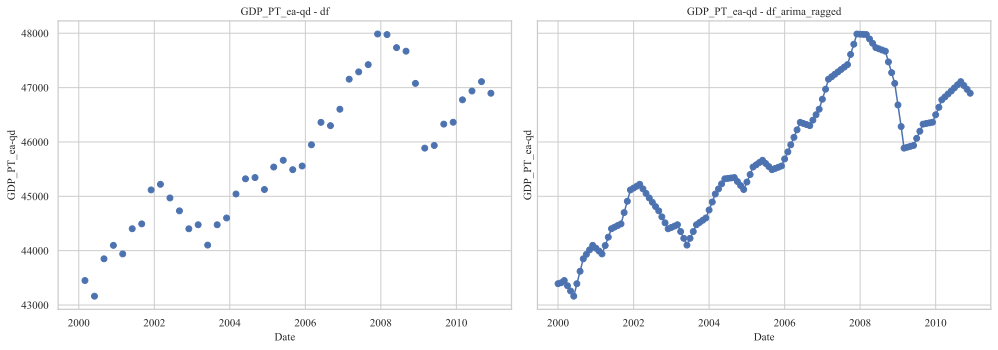

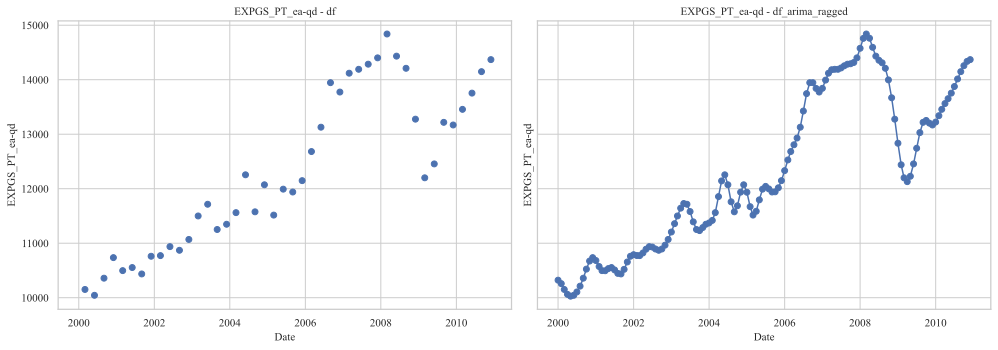

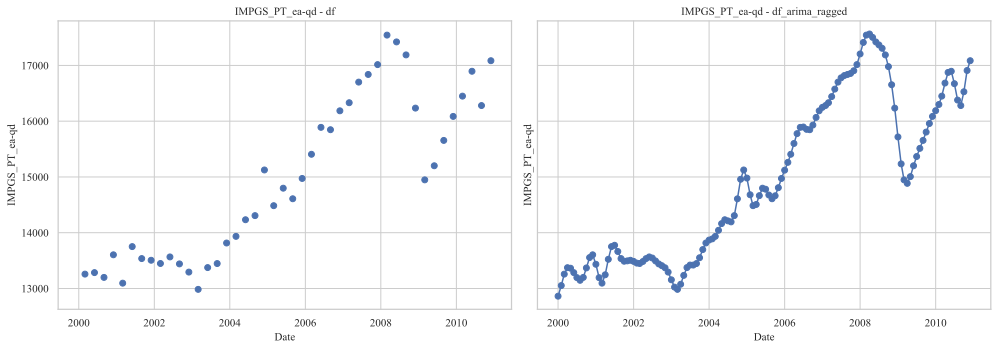

In [91]:
# Comparação lado a lado das séries trimestrais originais e preenchidas com Auto-ARIMA
start, end = "2000-01-01", "2010-12-01"
vars_q = [col for col in ea_qd.columns if col != "Date" and col in df.columns and col in df_arima_ragged.columns]

for col in vars_q[:3]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    fig.subplots_adjust(wspace=0.25)

    # Série original
    serie_df = df.loc[start:end, col].dropna()
    axes[0].plot(serie_df.index, serie_df.values, marker="o", linestyle="None")
    axes[0].set_title(f"{col} - df")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel(col)
    axes[0].grid(True)

    # Série preenchida com Auto-ARIMA
    serie_arima = df_arima_ragged.loc[start:end, col].dropna()
    axes[1].plot(serie_arima.index, serie_arima.values, marker="o", linestyle="-")
    axes[1].set_title(f"{col} - df_arima_ragged")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel(col)
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


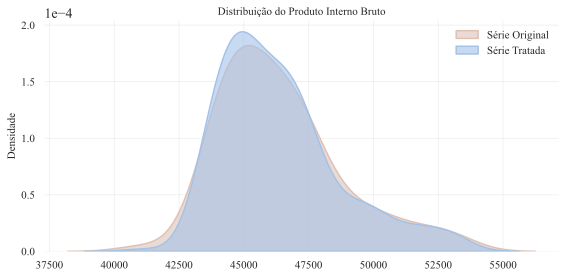

In [92]:
# Função densidade para as variáveis trimestrais - comparação entre série original e série com técnica híbrida

sns.set_theme(
    style="whitegrid",
    rc={
        "font.family": "Times New Roman",
        "font.size": 11,
        "axes.titlesize": 11,
        "axes.labelsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
    }
)

vars_q = ea_qd.columns.intersection(df.columns).intersection(df_arima_ragged.columns)

for col in vars_q[0:1]:
    fig, ax = plt.subplots(figsize=(8, 4))

    sns.kdeplot(
        df[col].dropna(),
        label="Série Original",
        fill=True,
        alpha=0.6,
        color="#ddc1b5",
        linewidth=1.5,
        ax=ax,
    )
    sns.kdeplot(
        df_arima_ragged[col].dropna(),
        label="Série Tratada",
        fill=True,
        alpha=0.6,
        color="#a3c2e7",
        linewidth=1.5,
        ax=ax,
    )

    ax.set_title(f"Distribuição do Produto Interno Bruto")
    ax.set_xlabel("")
    ax.set_ylabel("Densidade")
    ax.locator_params(axis="y", nbins=6)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_size(14)
    ax.yaxis.get_offset_text().set_family("Times New Roman")
    ax.legend(frameon=False)
    ax.grid(True, color="#d9d9d9", alpha=0.45, linewidth=0.8)
    sns.despine(ax=ax, left=True, bottom=True)

    plt.tight_layout()
    plt.show()


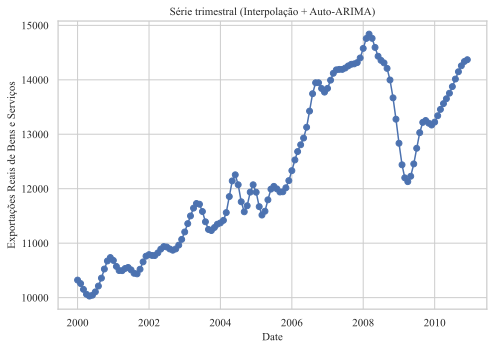

In [93]:
import matplotlib.pyplot as plt

start, end = "2000-01-01", "2010-12-01"
col = "EXPGS_PT_ea-qd"

serie = df_arima_ragged.loc[start:end, col].dropna()

plt.figure(figsize=(7, 5))
plt.plot(serie.index, serie.values, marker="o", linestyle="-")
plt.title(f"Série trimestral (Interpolação + Auto-ARIMA)")
plt.xlabel("Date")
plt.ylabel("Exportações Reais de Bens e Serviços")
plt.grid(True)
plt.tight_layout()
plt.show()

In [94]:
# Guardar o DataFrame final 
df_arima_ragged.to_csv("dados/train_complete.csv", index=True)

---